# Cataract Detection Using Ensemble Learning (LeNet-5 + MobileNetV2)

## 1. Imports and Constants
Logic:
All necessary libraries for data processing, model building, training, evaluation, and visualization are imported. Constants such as image size, batch size, epochs, and directory paths are defined for easy configuration.


In [4]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, AveragePooling2D, Dense, Flatten, 
                                     Dropout, BatchNormalization, Activation, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, roc_auc_score, 
                             confusion_matrix, classification_report, roc_curve, auc, f1_score)
import pandas as pd

# Constants
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 50
BASE_DIR = r"C:\Users\USER\Desktop\FYP\Cataract Detection\CataractDetection code\ML\processed_images"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
CLASS_NAMES = ['normal', 'cataract']

## 2. Preprocessing and Data Loading
Logic:
- equalize_histogram and remove_glare functions enhance image quality and reduce artifacts.
- load_data_both loads images for both models:
    - RGB images for MobileNetV2
    - Grayscale images for LeNet-5
    - Labels are assigned based on folder names.

Result:
- Data is loaded and preprocessed into arrays suitable for both models.
- Class distribution is printed to check for balance.

In [5]:
def equalize_histogram(img):
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    img_output = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    return img_output

def remove_glare(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY)
    result = cv2.inpaint(img, mask, 7, cv2.INPAINT_TELEA)
    return result

def load_data_both(data_dir):
    X_rgb, X_gray, y = [], [], []
    for class_name in CLASS_NAMES:
        class_path = os.path.join(data_dir, class_name)
        label = 1 if class_name == 'cataract' else 0
        if os.path.exists(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_name)
                    try:
                        img = cv2.imread(img_path)
                        if img is not None:
                            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                            img_rgb = remove_glare(img_rgb)
                            img_rgb = equalize_histogram(img_rgb)
                            img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
                            img_rgb = img_rgb.astype('float32') / 255.0
                            X_rgb.append(img_rgb)
                            # For LeNet-5 (grayscale)
                            img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
                            img_gray = np.expand_dims(img_gray, axis=-1)
                            X_gray.append(img_gray)
                            y.append(label)
                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")
    return np.array(X_rgb), np.array(X_gray), np.array(y)

## 3. Model Definitions
Logic:
- LeNet-5: A classic CNN adapted for grayscale images, with dropout and batch normalization to prevent overfitting.
- MobileNetV2: A modern, pre-trained CNN for RGB images, used as a feature extractor with a custom classification head.

Result:
- Both models are ready for training and ensemble use.

In [6]:
# LeNet-5 for grayscale
def create_lenet5(input_shape=(IMG_SIZE, IMG_SIZE, 1)):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (5, 5), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling2D((2, 2))(x)
    x = Dropout(0.4)(x)
    x = Conv2D(64, (5, 5), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling2D((2, 2))(x)
    x = Dropout(0.4)(x)
    x = Conv2D(120, (5, 5), padding='valid')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.4)(x)
    x = Flatten()(x)
    x = Dense(120)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.6)(x)
    x = Dense(84)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.6)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

# MobileNetV2 for RGB
def create_mobilenetv2(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

In [7]:
print("Loading data for both models...")
X_rgb, X_gray, y = load_data_both(TRAIN_DIR)
print(f"Loaded {len(X_rgb)} images")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Loading data for both models...
Loaded 491 images
Class distribution: [246 245]


## 4. K-Fold Ensemble Evaluation
Logic:
- kfold_ensemble_evaluation performs k-fold cross-validation:
- For each fold, both LeNet-5 and MobileNetV2 are trained on the training split.
- Predictions are made on the validation split.
- Ensemble prediction is the average of both models’ probabilities.
- Metrics (accuracy, precision, recall, AUC) are calculated for each fold.

Result:
- Fold-wise metrics are printed.
- Average and standard deviation for each metric are reported, providing a robust estimate of model performance.


In [8]:
def kfold_ensemble_evaluation(X_rgb, X_gray, y, n_splits=5, threshold=0.5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    fold = 1
    for train_idx, val_idx in kf.split(X_rgb):
        print(f"\n--- Fold {fold} ---")
        # Split data
        X_rgb_train, X_rgb_val = X_rgb[train_idx], X_rgb[val_idx]
        X_gray_train, X_gray_val = X_gray[train_idx], X_gray[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Train LeNet-5
        lenet5_model = create_lenet5()
        lenet5_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        lenet5_model.fit(
            X_gray_train, y_train,
            epochs=10,  # You can increase for better results
            batch_size=BATCH_SIZE,
            verbose=0
        )

        # Train MobileNetV2
        mobilenet_model = create_mobilenetv2()
        mobilenet_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        mobilenet_model.fit(
            X_rgb_train, y_train,
            epochs=10,  # You can increase for better results
            batch_size=BATCH_SIZE,
            verbose=0
        )

        # Predict on validation set
        p1 = lenet5_model.predict(X_gray_val).ravel()
        p2 = mobilenet_model.predict(X_rgb_val).ravel()
        p_ensemble = (p1 + p2) / 2
        y_pred = (p_ensemble >= threshold).astype(int)

        # Metrics
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=1)
        rec = recall_score(y_val, y_pred, zero_division=1)
        auc_score = roc_auc_score(y_val, p_ensemble)
        print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, AUC: {auc_score:.4f}")
        results.append({'accuracy': acc, 'precision': prec, 'recall': rec, 'auc': auc_score})
        fold += 1
    return results

## 5. K-Fold Metrics Visualization
Logic:
- A boxplot is generated to visualize the distribution of accuracy, precision, recall, and AUC across all folds.

Result:
- The plot shows that precision and AUC are consistently high, while recall varies more between folds, indicating some variability in the model’s ability to detect all positive cases.


--- Fold 1 ---


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 332ms/step
Accuracy: 0.9192, Precision: 0.9787, Recall: 0.8679, AUC: 0.9926

--- Fold 2 ---
3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step WARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000229982D65C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/ste

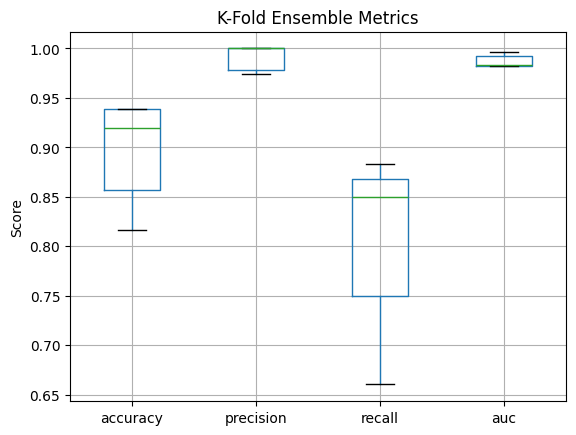

In [9]:
results = kfold_ensemble_evaluation(X_rgb, X_gray, y, n_splits=5, threshold=0.5)

# Print average results
print("\nAverage Results across all folds:")
for metric in ['accuracy', 'precision', 'recall', 'auc']:
    values = [fold[metric] for fold in results]
    print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Boxplot
df = pd.DataFrame(results)
df.boxplot()
plt.title("K-Fold Ensemble Metrics")
plt.ylabel("Score")
plt.show()

## 6. Final Model Training 
Logic:
- Both models can be trained on the full training set for deployment or further evaluation.

Result:
- Trained models are saved for later use in prediction or deployment.

In [10]:
# Split for final training
X_rgb_train, X_rgb_val, X_gray_train, X_gray_val, y_train, y_val = train_test_split(
    X_rgb, X_gray, y, test_size=0.2, random_state=42, stratify=y
)

# Train LeNet-5
lenet5_model = create_lenet5()
lenet5_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)
lenet5_model.fit(
    X_gray_train, y_train,
    validation_data=(X_gray_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
        ModelCheckpoint('lenet5_cataract_model.keras', monitor='val_accuracy', save_best_only=True)
    ]
)

# Train MobileNetV2
mobilenet_model = create_mobilenetv2()
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)
mobilenet_model.fit(
    X_rgb_train, y_train,
    validation_data=(X_rgb_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
        ModelCheckpoint('mobilenetv2_cataract_model.keras', monitor='val_accuracy', save_best_only=True)
    ]
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 314ms/step - accuracy: 0.6073 - auc: 0.6603 - loss: 0.7489 - precision: 0.6051 - recall: 0.6249 - val_accuracy: 0.5354 - val_auc: 0.7971 - val_loss: 0.6731 - val_precision: 1.0000 - val_recall: 0.0612 - learning_rate: 5.0000e-04
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 238ms/step - accuracy: 0.7500 - auc: 0.8511 - loss: 0.4784 - precision: 0.7457 - recall: 0.7388 - val_accuracy: 0.5152 - val_auc: 0.8541 - val_loss: 0.6689 - val_precision: 1.0000 - val_recall: 0.0204 - learning_rate: 5.0000e-04
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.8048 - auc: 0.8861 - loss: 0.4245 - precision: 0.8244 - recall: 0.7769 - val_accuracy: 0.5051 - val_auc: 0.8545 - val_loss: 0.7299 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - accuracy: 0.8147 - auc: 0.9142 - loss: 0.3779 - precision: 0.8669 - recall: 0.7586 - val_accuracy: 0.5051 - val_auc: 0.8447 - v

## 7. Ensemble Evaluation on Validation Set
Logic:
- Probabilities from both models are averaged for each validation sample.
- A confusion matrix is plotted to visualize true/false positives and negatives.
- An evaluation table (accuracy, precision, recall, F1, AUC) and a classification report are printed.

Result:
- The ensemble achieves high accuracy, precision, recall, and AUC on the validation set.
- The confusion matrix and classification report provide detailed insight into model performance for each class.

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step


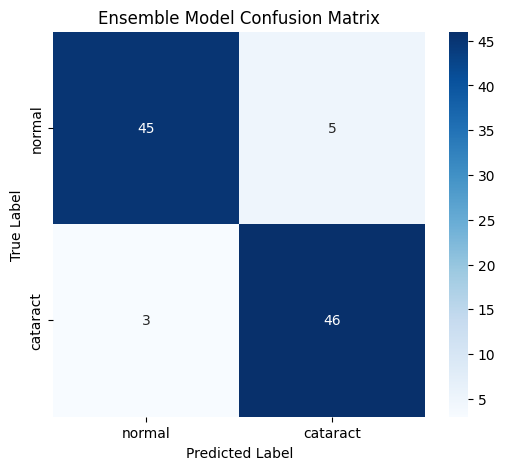

Ensemble Model Evaluation:
Accuracy : 0.9192
Precision: 0.9020
Recall   : 0.9388
F1 Score : 0.9200
AUC      : 0.9710

Classification Report:
              precision    recall  f1-score   support

      normal       0.94      0.90      0.92        50
    cataract       0.90      0.94      0.92        49

    accuracy                           0.92        99
   macro avg       0.92      0.92      0.92        99
weighted avg       0.92      0.92      0.92        99



In [11]:
# Get probabilities from both models
p1 = lenet5_model.predict(X_gray_val).ravel()
p2 = mobilenet_model.predict(X_rgb_val).ravel()

# Ensemble: average probabilities
p_ensemble = (p1 + p2) / 2

# Choose threshold (e.g., 0.5 or your optimal threshold)
threshold = 0.5
y_pred = (p_ensemble >= threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Ensemble Model Confusion Matrix')
plt.show()

# Evaluation Table
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, zero_division=1)
rec = recall_score(y_val, y_pred, zero_division=1)
f1 = f1_score(y_val, y_pred, zero_division=1)
auc_score = roc_auc_score(y_val, p_ensemble)

print("Ensemble Model Evaluation:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc_score:.4f}")

# Optionally, print a full classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, zero_division=1))

## 8. Single Image Ensemble Prediction
Logic:
- preprocess_for_ensemble prepares a new image for both models.
- ensemble_predict combines predictions from both models for a final decision.
- The input image is displayed for visual confirmation.

Result:
- The ensemble model can be used to predict cataract presence on new, unseen images, with the - prediction and confidence displayed alongside the input image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
LeNet-5: 42.15%, MobileNetV2: 99.74%, Ensemble: 70.95%


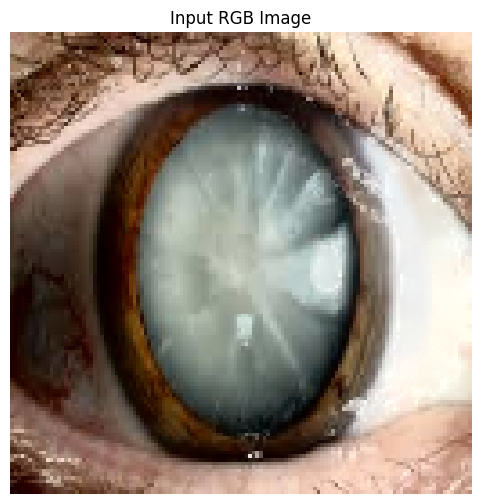

Ensemble Prediction: Cataract, Confidence: 70.95%


In [12]:
def preprocess_for_ensemble(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = remove_glare(img_rgb)
    img_rgb = equalize_histogram(img_rgb)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_rgb = img_rgb.astype('float32') / 255.0
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    img_gray = np.expand_dims(img_gray, axis=-1)
    return np.expand_dims(img_rgb, axis=0), np.expand_dims(img_gray, axis=0)

def ensemble_predict(img_rgb, img_gray, lenet5_model, mobilenet_model, threshold=0.5):
    p1 = lenet5_model.predict(img_gray)[0][0]
    p2 = mobilenet_model.predict(img_rgb)[0][0]
    p_ensemble = (p1 + p2) / 2
    result = "Cataract" if p_ensemble >= threshold else "Normal"
    print(f"LeNet-5: {p1:.2%}, MobileNetV2: {p2:.2%}, Ensemble: {p_ensemble:.2%}")
    return result, p_ensemble

# Example usage:
image_path = r"C:\Users\USER\Desktop\FYP\Cataract Detection\CataractDetection code\ML\cataract.jpg"
img_rgb, img_gray = preprocess_for_ensemble(image_path)
result, confidence = ensemble_predict(img_rgb, img_gray, lenet5_model, mobilenet_model, threshold=0.5)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb[0])
plt.title("Input RGB Image")
plt.axis('off')
plt.show()
print(f"Ensemble Prediction: {result}, Confidence: {confidence:.2%}")